# EVALUACIÓN DE MODELOS — DATASET FACEFORENSICS++ C0 (SIN COMPRESIÓN)

Evalúa los 4 modelos entrenados con C23 sobre imágenes de **máxima calidad (C0/raw)**.
Se espera que los modelos obtengan mejores métricas que en C40, ya que las manipulaciones
son más visibles al no haber pérdida por compresión.

In [1]:
import os
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import time
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, log_loss, roc_auc_score,
                             matthews_corrcoef, confusion_matrix)
import timm

# ==========================================
# 1. CONFIGURACIÓN DE RUTAS Y DISPOSITIVO
# ==========================================
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ⚠️ Ruta donde el notebook de procesamiento guardó las caras extraídas
PATH_C0 = r'C:\TFG\Dataset_C0_Procesado\test'

# Rutas a los pesos entrenados con C23 (mismos que en C40)
MODEL_PATHS = {
    "XceptionNet":      r"C:\TFG\modelos\best_xception_loss.pth",
    "EfficientNet-B3":  r"C:\TFG\modelos\best_effnet_loss.pth",
    "MesoInception-4":  r"C:\TFG\modelos\best_mesoinception_mejorado_loss.pth",
    "ViT":              r"C:\TFG\modelos\best_vit_loss.pth"
}

print(f"🔥 Evaluando en: {DEVICE}")
print(f"📁 Dataset C0: {PATH_C0}")

🔥 Evaluando en: cuda
📁 Dataset C0: C:\TFG\Dataset_C0_Procesado\test


In [2]:
# ==========================================
# 2. CLASE DATASET
# ==========================================
class DeepfakeDatasetC0(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []

        for label in ['real', 'fake']:
            folder = os.path.join(root_dir, label)
            if os.path.exists(folder):
                for img in os.listdir(folder):
                    if img.lower().endswith(('.jpg', '.jpeg', '.png')):
                        self.samples.append((os.path.join(folder, img), 0 if label == 'real' else 1))

        if len(self.samples) == 0:
            raise RuntimeError(f"No se encontraron imágenes en {root_dir}")

        reales = sum(1 for _, l in self.samples if l == 0)
        fakes  = sum(1 for _, l in self.samples if l == 1)
        print(f"📊 Dataset C0 cargado: {len(self.samples)} imágenes (Real: {reales} | Fake: {fakes})")

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

In [3]:
# ==========================================
# 3. DEFINICIÓN DE MESOINCEPTION-4
# ==========================================
class MesoInception4(nn.Module):
    def __init__(self, num_classes=2):
        super(MesoInception4, self).__init__()
        self.inception1 = self._inception_layer(3, 8, 8, 8, 8)
        self.inception2 = self._inception_layer(32, 8, 16, 16, 8)
        self.conv3 = nn.Conv2d(48, 64, kernel_size=5, padding=2)
        self.relu = nn.ReLU()
        self.leaky_relu = nn.LeakyReLU(0.1)
        self.bn1 = nn.BatchNorm2d(64)
        self.maxpool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm2d(64)
        self.maxpool2 = nn.MaxPool2d(kernel_size=4, stride=4)
        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(64 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def _inception_layer(self, in_channels, out1, out2, out3, out4):
        conv1 = nn.Sequential(nn.Conv2d(in_channels, out1, kernel_size=1, padding=0), nn.BatchNorm2d(out1), nn.ReLU())
        conv2 = nn.Sequential(nn.Conv2d(in_channels, out2, kernel_size=3, padding=1), nn.BatchNorm2d(out2), nn.ReLU())
        conv3 = nn.Sequential(nn.Conv2d(in_channels, out3, kernel_size=5, padding=2), nn.BatchNorm2d(out3), nn.ReLU())
        conv4 = nn.Sequential(nn.Conv2d(in_channels, out4, kernel_size=7, padding=3), nn.BatchNorm2d(out4), nn.ReLU())
        return nn.ModuleList([conv1, conv2, conv3, conv4])

    def forward(self, x):
        x = torch.cat([layer(x) for layer in self.inception1], 1)
        x = nn.MaxPool2d(kernel_size=2, stride=2)(x)
        x = torch.cat([layer(x) for layer in self.inception2], 1)
        x = nn.MaxPool2d(kernel_size=2, stride=2)(x)
        x = self.relu(self.bn1(self.conv3(x)))
        x = self.maxpool1(x)
        x = self.relu(self.bn2(self.conv4(x)))
        x = self.maxpool2(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.leaky_relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

In [4]:
# ==========================================
# 4. FUNCIONES AUXILIARES DE MÉTRICAS
# ==========================================
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def evaluate_all_metrics(name, y_true, y_prob, time_ms, params):
    y_pred = (y_prob > 0.5).astype(int)
    return {
        "Modelo":  name,
        "Acc":     accuracy_score(y_true, y_pred),
        "Prec":    precision_score(y_true, y_pred, zero_division=0),
        "Rec":     recall_score(y_true, y_pred, zero_division=0),
        "F1":      f1_score(y_true, y_pred, zero_division=0),
        "AUC":     roc_auc_score(y_true, y_prob),
        "Loss":    log_loss(y_true, y_prob, labels=[0, 1]),
        "MCC":     matthews_corrcoef(y_true, y_pred),
        "Time_ms": time_ms,
        "Params":  params
    }

def run_inference(model, test_loader, model_name):
    model.eval()
    model.to(DEVICE)
    y_true, y_prob = [], []
    start_time = time.time()

    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc=f"🔍 Inferencia {model_name}"):
            inputs = inputs.to(DEVICE)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
            y_prob.extend(probs)
            y_true.extend(labels.numpy())

    time_per_image_ms = ((time.time() - start_time) / len(y_true)) * 1000
    return np.array(y_true), np.array(y_prob), time_per_image_ms

# Transformaciones por modelo (idénticas a C40)
transforms_dict = {
    "XceptionNet": transforms.Compose([
        transforms.Resize((299, 299)), transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ]),
    "EfficientNet-B3": transforms.Compose([
        transforms.Resize((300, 300)), transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    "MesoInception-4": transforms.Compose([
        transforms.Resize((256, 256)), transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ]),
    "ViT": transforms.Compose([
        transforms.Resize((224, 224)), transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ])
}

In [5]:
# ==========================================
# 5. BUCLE PRINCIPAL DE EVALUACIÓN
# ==========================================
resultados = []
resultados_matrices = {}

for nombre, path in MODEL_PATHS.items():
    print(f"\n🚀 Preparando evaluación de: {nombre}")

    try:
        # 1. Instanciar arquitectura
        if nombre == "XceptionNet":
            model = timm.create_model('xception', pretrained=False, num_classes=2)
        elif nombre == "EfficientNet-B3":
            model = timm.create_model('tf_efficientnet_b3', pretrained=False, num_classes=2)
        elif nombre == "MesoInception-4":
            model = MesoInception4(num_classes=2)
        elif nombre == "ViT":
            model = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=2)

        # 2. Cargar pesos
        model.load_state_dict(torch.load(path, map_location=DEVICE))

        # 3. Dataset y DataLoader
        dataset = DeepfakeDatasetC0(PATH_C0, transform=transforms_dict[nombre])
        loader  = DataLoader(dataset, batch_size=32, shuffle=False)

        # 4. Inferencia
        y_true, y_prob, t_ms = run_inference(model, loader, nombre)

        # 5. Métricas
        metricas = evaluate_all_metrics(nombre, y_true, y_prob, t_ms, count_parameters(model))
        resultados.append(metricas)

        # 6. Matriz de confusión
        y_pred = (y_prob > 0.5).astype(int)
        resultados_matrices[nombre] = confusion_matrix(y_true, y_pred)

        print(f"✅ {nombre} → Acc: {metricas['Acc']:.4f} | AUC: {metricas['AUC']:.4f} | F1: {metricas['F1']:.4f}")

    except Exception as e:
        print(f"❌ Error evaluando {nombre}: {e}")

# ==========================================
# 6. TABLA FINAL
# ==========================================
df_final = pd.DataFrame(resultados)
print("\n" + "="*80)
print("📊 RESULTADOS FINALES SOBRE DATASET C0 (SIN COMPRESIÓN)")
print("="*80)
print(df_final[['Modelo', 'Acc', 'AUC', 'Loss', 'MCC', 'Time_ms']].to_string(index=False))
print("="*80)

df_final.to_csv("Resultados_Comparativa_C0.csv", index=False)
print("\n💾 Guardado en Resultados_Comparativa_C0.csv")


🚀 Preparando evaluación de: XceptionNet


c:\TFG\venv_tfg\Lib\site-packages\timm\models\_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(
C:\Users\User\AppData\Local\Temp\ipykernel_31924\2854779599.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of

📊 Dataset C0 cargado: 6000 imágenes (Real: 3000 | Fake: 3000)


🔍 Inferencia XceptionNet: 100%|██████████| 188/188 [01:33<00:00,  2.02it/s]


✅ XceptionNet → Acc: 0.9490 | AUC: 0.9986 | F1: 0.9512

🚀 Preparando evaluación de: EfficientNet-B3


...

✅ MesoInception-4 → Acc: 0.7435 | AUC: 0.8388 | F1: 0.7144

🚀 Preparando evaluación de: ViT


C:\Users\User\AppData\Local\Temp\ipykernel_31924\2854779599.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path, map_location=DEVICE))

📊 Dataset C0 cargado: 6000 imágenes (Real: 3000 | Fake: 3000)


🔍 Inferencia ViT: 100%|██████████| 188/188 [00:52<00:00,  3.55it/s]

✅ ViT → Acc: 0.9883 | AUC: 0.9989 | F1: 0.9884

📊 RESULTADOS FINALES SOBRE DATASET C0 (SIN COMPRESIÓN)
         Modelo      Acc      AUC     Loss      MCC   Time_ms
    XceptionNet 0.949000 0.998586 0.118120 0.901769 15.530902
EfficientNet-B3 0.912667 0.996941 0.209239 0.837233  6.605758
MesoInception-4 0.743500 0.838795 0.522094 0.497426  3.451609
            ViT 0.988333 0.998880 0.077441 0.976681  8.826696

💾 Guardado en Resultados_Comparativa_C0.csv


# Métricas

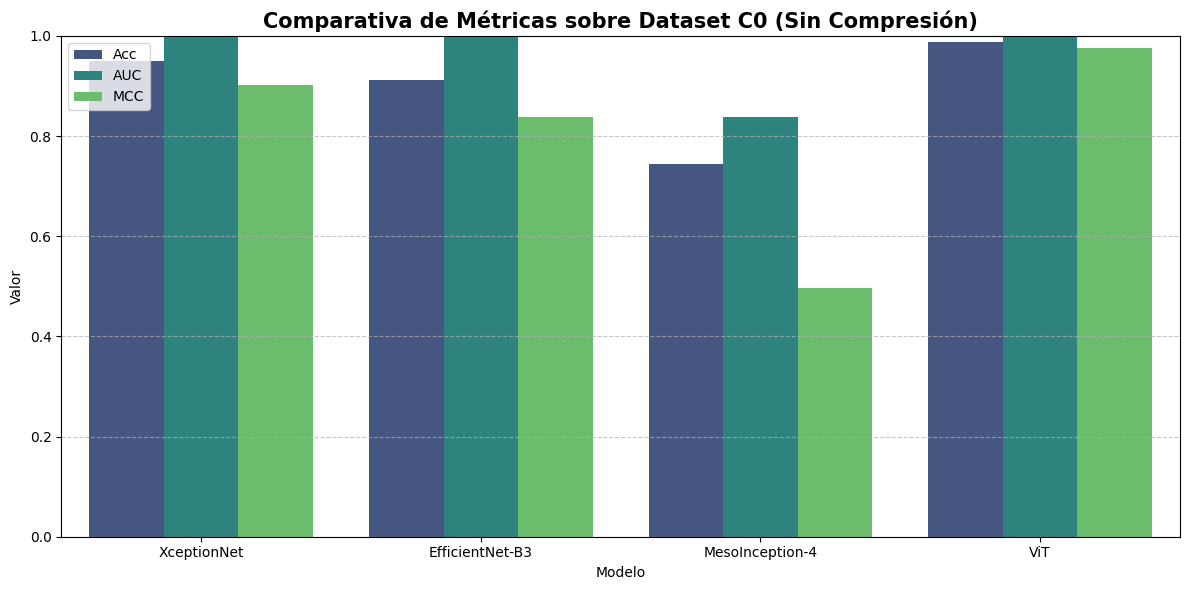

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

df_plot   = df_final[['Modelo', 'Acc', 'AUC', 'MCC']].copy()
df_melted = df_plot.melt(id_vars='Modelo', var_name='Métrica', value_name='Valor')

plt.figure(figsize=(12, 6))
sns.barplot(data=df_melted, x='Modelo', y='Valor', hue='Métrica', palette='viridis')

plt.title('Comparativa de Métricas sobre Dataset C0 (Sin Compresión)', fontsize=15, fontweight='bold')
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig('barras_C0.png', dpi=150, bbox_inches='tight')
plt.show()


🚀 Evaluando XceptionNet...


c:\TFG\venv_tfg\Lib\site-packages\timm\models\_factory.py:138: UserWarning: Mapping deprecated model name xception to current legacy_xception.
  model = create_fn(
C:\Users\User\AppData\Local\Temp\ipykernel_31924\3720804538.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of

📊 Dataset C0 cargado: 6000 imágenes (Real: 3000 | Fake: 3000)


🔍 XceptionNet: 100%|██████████| 188/188 [00:43<00:00,  4.32it/s]
C:\Users\User\AppData\Local\Temp\ipykernel_31924\3720804538.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental featur

✅ Matriz de XceptionNet generada.

🚀 Evaluando EfficientNet-B3...
📊 Dataset C0 cargado: 6000 imágenes (Real: 3000 | Fake: 3000)


...

✅ Matriz de MesoInception-4 generada.

🚀 Evaluando ViT...


C:\Users\User\AppData\Local\Temp\ipykernel_31924\3720804538.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_eval.load_state_dict(torch.load(path, map_location=DEV

📊 Dataset C0 cargado: 6000 imágenes (Real: 3000 | Fake: 3000)


🔍 ViT: 100%|██████████| 188/188 [00:53<00:00,  3.53it/s]


✅ Matriz de ViT generada.


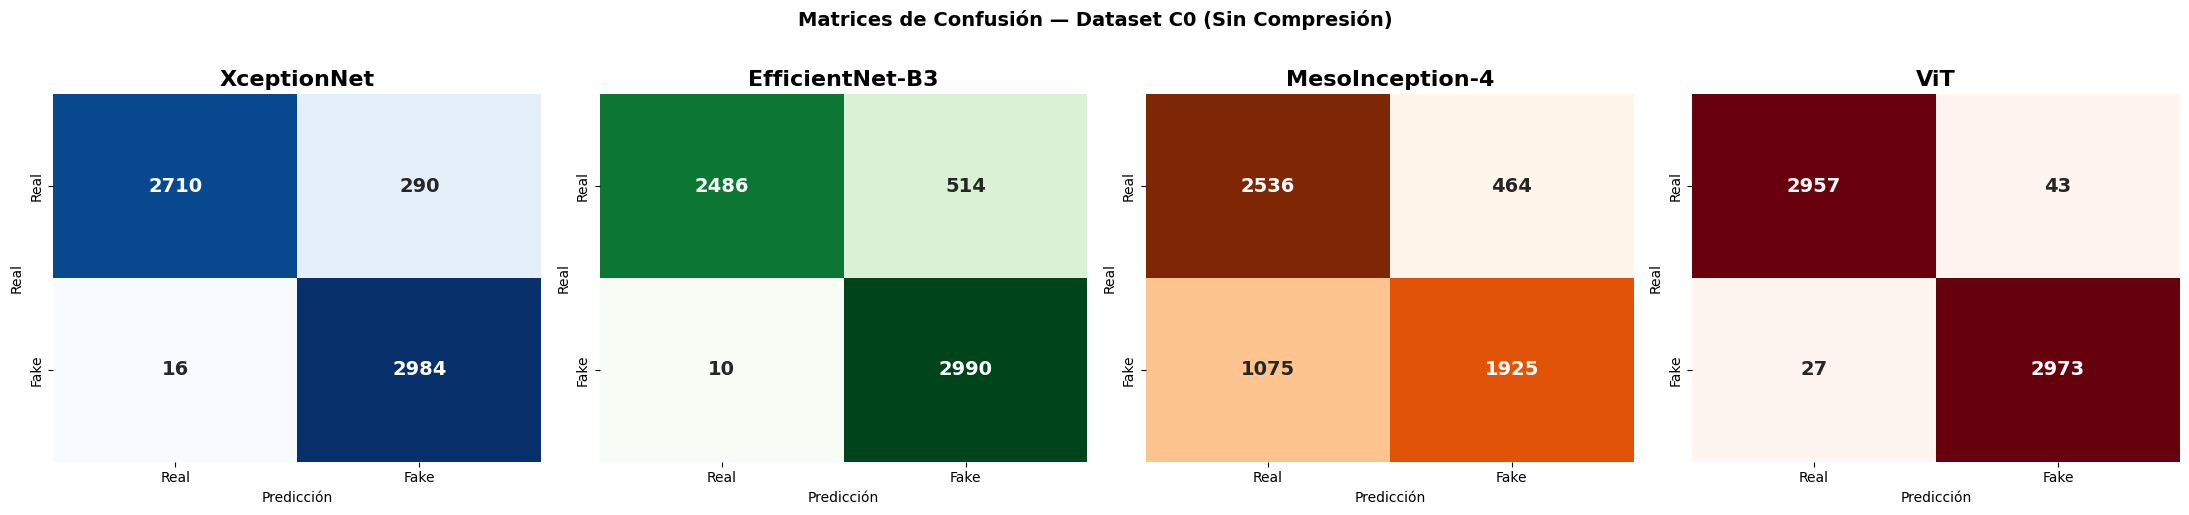

In [7]:
# ==========================================
# MATRICES DE CONFUSIÓN
# ==========================================
import os
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

resultados_matrices = {}

for nombre, path in MODEL_PATHS.items():
    print(f"\n🚀 Evaluando {nombre}...")

    try:
        if nombre == "XceptionNet":
            model_eval = timm.create_model('xception', pretrained=False, num_classes=2)
        elif nombre == "EfficientNet-B3":
            model_eval = timm.create_model('tf_efficientnet_b3', pretrained=False, num_classes=2)
        elif nombre == "MesoInception-4":
            model_eval = MesoInception4(num_classes=2)
        elif nombre == "ViT":
            model_eval = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=2)

        model_eval.load_state_dict(torch.load(path, map_location=DEVICE))
        model_eval.to(DEVICE)
        model_eval.eval()

        dataset_eval = DeepfakeDatasetC0(PATH_C0, transform=transforms_dict[nombre])
        loader_eval  = DataLoader(dataset_eval, batch_size=32, shuffle=False)

        y_true_list, y_prob_list = [], []
        with torch.no_grad():
            for inputs, labels in tqdm(loader_eval, desc=f"🔍 {nombre}"):
                inputs = inputs.to(DEVICE)
                outputs = model_eval(inputs)
                probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
                y_prob_list.extend(probs)
                y_true_list.extend(labels.numpy())

        y_pred_final = (np.array(y_prob_list) > 0.5).astype(int)
        resultados_matrices[nombre] = confusion_matrix(y_true_list, y_pred_final)
        print(f"✅ Matriz de {nombre} generada.")

    except Exception as e:
        print(f"❌ Error evaluando {nombre}: {e}")

# Dibujar las 4 matrices
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
cmaps = ['Blues', 'Greens', 'Oranges', 'Reds']

for i, (nombre, matrix) in enumerate(resultados_matrices.items()):
    sns.heatmap(matrix, annot=True, fmt='d', ax=axes[i], cmap=cmaps[i], cbar=False,
                annot_kws={'size': 14, 'weight': 'bold'})
    axes[i].set_title(nombre, fontsize=16, fontweight='bold')
    axes[i].set_xlabel('Predicción')
    axes[i].set_ylabel('Real')
    axes[i].set_xticklabels(['Real', 'Fake'])
    axes[i].set_yticklabels(['Real', 'Fake'])

plt.suptitle('Matrices de Confusión — Dataset C0 (Sin Compresión)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices_C0.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# ==========================================
# TABLA COMPARATIVA C0 CON COLUMNAS COLOREADAS
# ==========================================
import pandas as pd
import seaborn as sns

df_metricas = pd.DataFrame(resultados).copy()

if 'Params' in df_metricas.columns:
    df_metricas['Params'] = df_metricas['Params'] / 1_000_000

df_metricas.set_index('Modelo', inplace=True)

cm_good = sns.light_palette('seagreen',   as_cmap=True)
cm_bad  = sns.light_palette('indianred',  as_cmap=True)

display(df_metricas.style
    .background_gradient(cmap=cm_good, subset=['Acc', 'Prec', 'Rec', 'F1', 'AUC', 'MCC'])
    .background_gradient(cmap=cm_bad,  subset=['Loss', 'Time_ms', 'Params'])
    .format('{:.4f}')
    .format('{:.2f}M', subset=['Params'])
    .set_caption('📊 Resultados sobre C0 (Sin Compresión)')
)

,Acc,Prec,Rec,F1,AUC,Loss,MCC,Time_ms,Params
Modelo,,,,,,,,,
XceptionNet,0.9490,0.9114,0.9947,0.9512,0.9986,0.1181,0.9018,15.5309,20.81M
EfficientNet-B3,0.9127,0.8533,0.9967,0.9194,0.9969,0.2092,0.8372,6.6058,10.70M
MesoInception-4,0.7435,0.8058,0.6417,0.7144,0.8388,0.5221,0.4974,3.4516,1.26M
ViT,0.9883,0.9857,0.9910,0.9884,0.9989,0.0774,0.9767,8.8267,85.80M
